In [2]:
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [3]:
df = pd.read_csv("student_mental_health_burnout.csv")
df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [4]:
df.shape

(150000, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

In [6]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level'],
      dtype='object')

In [7]:
df.isnull().sum()

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['burnout_level'].value_counts()

burnout_level
Low       50265
Medium    49969
High      49766
Name: count, dtype: int64

Spliting data

In [10]:
x = df.drop('burnout_level', axis=1)
y = df['burnout_level']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
x_train.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality
67987,167988,21,Other,BSc,3rd,4.1,7.7,8.9,Low,9,10,9,6,7,1.4,Good,58.6,4.07,Average
48476,148477,19,Male,BSc,3rd,6.2,8.1,6.6,Medium,1,2,10,6,3,1.5,Good,66.3,7.73,Poor
86254,186255,20,Female,MCA,1st,5.6,4.3,8.5,Low,6,10,5,3,7,1.2,Good,54.3,7.23,Average
44348,144349,20,Other,BTech,3rd,1.6,5.0,2.2,High,8,3,3,8,6,1.6,Good,87.6,6.32,Average
117352,217353,22,Other,BBA,2nd,1.7,8.2,11.0,Low,8,9,1,10,10,1.1,Poor,52.7,7.48,Good


In [12]:
y_train.head()

67987        Low
48476        Low
86254     Medium
44348       High
117352      High
Name: burnout_level, dtype: object

In [13]:
x_train.columns

Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality'],
      dtype='object')

In [14]:
if 'student_id' in x_train.columns:
    x_train = x_train.drop('student_id', axis=1)
    x_test = x_test.drop('student_id', axis=1)

cat_feat = x_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_feat = x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

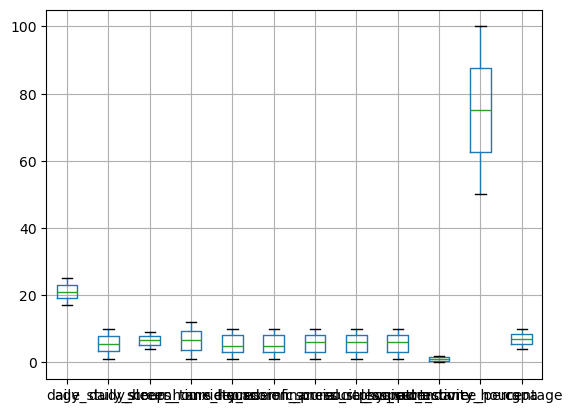

In [15]:
boxplot = x_train.boxplot(column=num_feat)
plt.show()

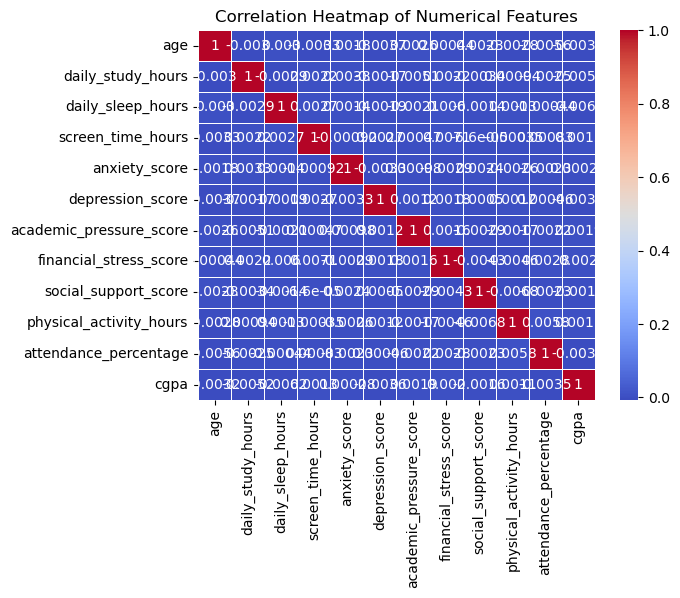

In [16]:
corr_matrix = x_train[num_feat].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)      
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [17]:
numeric_preprocess = Pipeline([('num_imputer', SimpleImputer(strategy='mean'))])

categorical_preprocess= Pipeline([('cat_imputer', SimpleImputer(strategy='most_frequent')),
                                  ('cat_encoder', OrdinalEncoder(categories=[
                                      ['Male', 'Female', 'Other'],                   
                                      ['BTech', 'BCA', 'BSc', 'MBA', 'MCA', 'BBA'], 
                                      ['Low', 'Medium', 'High'],                    
                                      ['Poor', 'Average', 'Good'],                  
                                      ['Poor', 'Average', 'Good']                    
                                  ]))])

In [18]:
preprocess = ColumnTransformer(transformers=[
    ('numPreprocess', numeric_preprocess, num_feat),
    ('catPreprocess', categorical_preprocess, (['gender', 'course', 'stress_level', 'sleep_quality', 'internet_quality']))
    ],
    remainder='drop')

preprocess

,transformers,"[('numPreprocess', ...), ('catPreprocess', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [19]:
x_train_preprocess = preprocess.fit_transform(x_train)
print("x_train_preprocess shape:", x_train_preprocess.shape)

x_train_preprocess shape: (120000, 17)


In [20]:
burnout_pred = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', RandomForestClassifier(criterion= 'gini', max_depth=4))
])

burnout_pred.fit(x_train, y_train)
y_predict = burnout_pred.predict(x_test)

print('\nClassification Report\n')
print(classification_report(y_test, y_predict))


Classification Report

              precision    recall  f1-score   support

        High       0.32      0.13      0.19      9953
         Low       0.34      0.62      0.44     10053
      Medium       0.33      0.24      0.28      9994

    accuracy                           0.33     30000
   macro avg       0.33      0.33      0.30     30000
weighted avg       0.33      0.33      0.30     30000

